# Partie II — CNN sur images Roboflow/YOLO

**Projet Deep Learning EMSI — FootAI**  
Notebook autonome consacré à la vision par ordinateur.

**Version mise à jour : dataset Roboflow `project11-vwk2l / x_321_5star / version 8`.**

## Objectif de la partie

Utiliser un dataset image réel exporté depuis **Roboflow au format YOLOv8**, convertir les annotations de détection en **crops classifiés**, puis comparer un **MLP image aplatie** avec plusieurs variantes de **CNN**.

## Plan du notebook

1. Installation, imports et fonctions communes.
2. Configuration Roboflow.
3. Conversion YOLO detection → crops de classification.
4. Corrélation croisée 2D, max-pooling et average-pooling manuels.
5. Chargement des images avec `ImageFolder`.
6. MLP image aplatie et CNN type LeNet.
7. Étude expérimentale : padding, stride, pooling, nombre de filtres, convolution 1×1.
8. Matrice de confusion et feature maps.
9. Analyse critique et synthèse.


## Pourquoi CNN plutôt que MLP pour les images ?

Un MLP aplatie l'image et perd une partie de la structure spatiale. Un CNN est plus adapté car il exploite :

- la **localité** : les pixels voisins portent souvent une information commune ;
- le **partage des poids** : un même filtre est appliqué sur toute l'image ;
- la **hiérarchie des représentations** : les premières couches détectent des motifs simples, les couches suivantes combinent ces motifs.

La taille de sortie d'une convolution 2D peut être vérifiée avec :

```text
H_out = floor((H_in + 2*padding - kernel_size) / stride) + 1
W_out = floor((W_in + 2*padding - kernel_size) / stride) + 1
```


In [2]:
# ============================================================
# 0. Installation minimale
# ============================================================

import sys, subprocess, importlib.util

def pip_install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Colab possède déjà torch/torchvision dans la majorité des cas.
required = {
    "requests": "requests",
    "yaml": "pyyaml",
    "sklearn": "scikit-learn",
    "PIL": "pillow",
    "tqdm": "tqdm",
    "roboflow": "roboflow",
}

for import_name, package_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        pip_install(package_name)

print("Installations vérifiées.")


Installations vérifiées.


In [3]:
# ============================================================
# 0. Imports et configuration générale
# ============================================================

import os
import re
import math
import json
import random
import shutil
import zipfile
import requests
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms, datasets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/content/FootAI_Partie2_CNN")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR = OUTPUT_DIR / "figures"

for p in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", DEVICE)


Device utilisé : cuda


In [4]:
# ============================================================
# 0. Fonctions communes
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


def compute_classification_metrics(y_true, y_pred, labels=None):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_confusion_matrix_simple(y_true, y_pred, class_names, title="Matrice de confusion", save_name=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Vraie classe")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()


def plot_training_curves(history, title="Courbes d'entraînement", save_name=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history.get("train_loss", []), label="train loss")
    ax.plot(history.get("val_loss", []), label="val loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()

    if "train_acc" in history and "val_acc" in history:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(history["train_acc"], label="train accuracy")
        ax.plot(history["val_acc"], label="val accuracy")
        ax.set_title(title + " - Accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        if save_name:
            fig.savefig(FIG_DIR / ("acc_" + save_name), dpi=150, bbox_inches="tight")
        plt.show()


def save_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)


def load_checkpoint(model, path, device=DEVICE):
    model.load_state_dict(torch.load(path, map_location=device))
    return model


def train_classifier(model, train_loader, val_loader, epochs=8, lr=1e-3, device=DEVICE, clip_norm=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_f1 = -1

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_true, train_pred = [], [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.step()

            train_losses.append(loss.item())
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            train_pred.extend(preds)
            train_true.extend(yb.detach().cpu().numpy())

        val_loss, val_metrics, _, _ = evaluate_classifier(model, val_loader, device=device, return_preds=True)
        train_metrics = compute_classification_metrics(train_true, train_pred)

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={history['train_loss'][-1]:.4f} | val_loss={val_loss:.4f} | val_f1={val_metrics['f1']:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_state


@torch.no_grad()
def evaluate_classifier(model, loader, device=DEVICE, return_preds=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses, y_true, y_pred = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        losses.append(loss.item())
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.cpu().numpy())

    metrics = compute_classification_metrics(y_true, y_pred)
    mean_loss = float(np.mean(losses)) if losses else 0.0

    if return_preds:
        return mean_loss, metrics, np.array(y_true), np.array(y_pred)
    return mean_loss, metrics


## Vérification rapide

Cette cellule confirme que le notebook utilise le bon dossier de travail et le bon device.


In [5]:

print("Projet :", PROJECT_DIR)
print("Dossier outputs :", OUTPUT_DIR)
print("Device :", DEVICE)


Projet : /content/FootAI_Partie2_CNN
Dossier outputs : /content/FootAI_Partie2_CNN/outputs
Device : cuda


# Partie II — CNN sur images Roboflow/YOLO

## Objectif

On garde **Roboflow + YOLO**, mais on simplifie la tâche :

1. Télécharger ou importer un dataset football au format YOLOv8.
2. Utiliser les boîtes YOLO pour créer des crops d'objets.
3. Transformer le problème de détection en problème de classification d'images.
4. Comparer un MLP image aplatie avec un CNN simple.

Cette approche respecte la partie CNN du projet, sans entraîner un détecteur YOLO complet.


In [6]:
# ============================================================
# 2. Configuration Roboflow / YOLO
# ============================================================

# Dataset Roboflow fourni pour la partie CNN
# Code de base fourni :
# from roboflow import Roboflow
# rf = Roboflow(api_key="zhqElQjyYwedrbnIETdH")
# project = rf.workspace("project11-vwk2l").project("x_321_5star")
# version = project.version(8)
# dataset = version.download("yolov8")

ROBOFLOW_API_KEY = "zhqElQjyYwedrbnIETdH"
ROBOFLOW_WORKSPACE = "project11-vwk2l"
ROBOFLOW_PROJECT = "x_321_5star"
ROBOFLOW_VERSION = 8

# Option de secours : upload manuel d'un export YOLOv8 zip dans Colab
# Dans Colab : panneau gauche > Files > Upload > football_yolo.zip
YOLO_ZIP_PATH = Path("/content/football_yolo.zip")

YOLO_DATA_DIR = DATA_DIR / "roboflow_yolo"
YOLO_DATA_DIR.mkdir(parents=True, exist_ok=True)


def find_data_yaml(root):
    root = Path(root)
    files = list(root.rglob("data.yaml")) + list(root.rglob("data.yml"))
    if not files:
        return None
    return files[0]


def download_roboflow_dataset():
    """Télécharge le dataset Roboflow en format YOLOv8."""
    from roboflow import Roboflow

    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    version = project.version(ROBOFLOW_VERSION)

    # On fixe le dossier de téléchargement pour garder un notebook propre.
    download_location = YOLO_DATA_DIR / f"{ROBOFLOW_PROJECT}-{ROBOFLOW_VERSION}"
    dataset = version.download("yolov8", location=str(download_location))

    print("Dataset Roboflow téléchargé dans :", dataset.location)
    return Path(dataset.location)


def prepare_yolo_dataset():
    """
    Prépare le dataset YOLOv8.
    Priorité :
    1. réutiliser un dataset déjà téléchargé ;
    2. télécharger depuis Roboflow ;
    3. utiliser /content/football_yolo.zip si disponible.
    """
    # 1) Réutiliser le dataset si data.yaml existe déjà
    existing_yaml = find_data_yaml(YOLO_DATA_DIR)
    if existing_yaml is not None:
        print("Dataset déjà présent. data.yaml trouvé :", existing_yaml)
        return existing_yaml.parent

    # 2) Télécharger depuis Roboflow
    try:
        return download_roboflow_dataset()
    except Exception as e:
        print("Téléchargement Roboflow impossible :", repr(e))
        print("Tentative avec le zip local si disponible...")

    # 3) Zip local
    if YOLO_ZIP_PATH.exists():
        print("Extraction du zip local :", YOLO_ZIP_PATH)
        if YOLO_DATA_DIR.exists():
            shutil.rmtree(YOLO_DATA_DIR)
        YOLO_DATA_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(YOLO_ZIP_PATH, "r") as z:
            z.extractall(YOLO_DATA_DIR)
        data_yaml = find_data_yaml(YOLO_DATA_DIR)
        if data_yaml is None:
            raise FileNotFoundError("Aucun data.yaml trouvé dans le zip YOLO.")
        return data_yaml.parent

    raise RuntimeError(
        "Aucun dataset YOLO trouvé. Vérifie la clé Roboflow ou upload un fichier "
        "/content/football_yolo.zip exporté depuis Roboflow au format YOLOv8."
    )


# Exécution : téléchargement/préparation du dataset image
# Remarque : si tu relances le notebook, il réutilise le dataset déjà téléchargé.
yolo_root = prepare_yolo_dataset()
print("Racine YOLO :", yolo_root)
print("data.yaml :", find_data_yaml(yolo_root))



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/FootAI_Partie2_CNN/data/roboflow_yolo/x_321_5star-8 in yolov8:: 100%|██████████| 16035/16035 [00:05<00:00, 2929.12it/s]


Dataset Roboflow téléchargé dans : /content/FootAI_Partie2_CNN/data/roboflow_yolo/x_321_5star-8
Racine YOLO : /content/FootAI_Partie2_CNN/data/roboflow_yolo/x_321_5star-8
data.yaml : /content/FootAI_Partie2_CNN/data/roboflow_yolo/x_321_5star-8/data.yaml


In [7]:
# ============================================================
# 2. Conversion YOLO detection -> crops de classification
# ============================================================

CROP_ROOT = DATA_DIR / "football_crops_classification"


def load_yolo_names(data_yaml_path):
    with open(data_yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)
    names = data.get("names", [])
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]
    return list(names)


def yolo_to_pixel_bbox(line, img_w, img_h):
    parts = line.strip().split()
    if len(parts) < 5:
        return None
    cls_id = int(float(parts[0]))
    x_c, y_c, w, h = map(float, parts[1:5])
    x1 = int((x_c - w/2) * img_w)
    y1 = int((y_c - h/2) * img_h)
    x2 = int((x_c + w/2) * img_w)
    y2 = int((y_c + h/2) * img_h)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    if x2 <= x1 or y2 <= y1:
        return None
    return cls_id, x1, y1, x2, y2


def convert_yolo_to_crops(yolo_root, crop_root, max_crops_per_class=700):
    yolo_root = Path(yolo_root)
    crop_root = Path(crop_root)
    if crop_root.exists():
        shutil.rmtree(crop_root)
    crop_root.mkdir(parents=True, exist_ok=True)

    data_yaml = find_data_yaml(yolo_root)
    if data_yaml is None:
        raise FileNotFoundError("data.yaml introuvable")

    class_names = load_yolo_names(data_yaml)
    counters = defaultdict(int)

    image_dirs = [p for p in yolo_root.rglob("images") if p.is_dir()]
    print("Dossiers images trouvés :", image_dirs)

    for img_dir in image_dirs:
        label_dir = Path(str(img_dir).replace("images", "labels"))
        if not label_dir.exists():
            continue

        image_files = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
            image_files.extend(list(img_dir.glob(ext)))

        for img_path in tqdm(image_files, desc=f"Crops {img_dir.parent.name}"):
            label_path = label_dir / (img_path.stem + ".txt")
            if not label_path.exists():
                continue

            img = Image.open(img_path).convert("RGB")
            img_w, img_h = img.size

            with open(label_path, "r", encoding="utf-8") as f:
                lines = [line for line in f.readlines() if line.strip()]

            for k, line in enumerate(lines):
                bbox = yolo_to_pixel_bbox(line, img_w, img_h)
                if bbox is None:
                    continue
                cls_id, x1, y1, x2, y2 = bbox
                if cls_id >= len(class_names):
                    continue
                class_name = str(class_names[cls_id]).replace("/", "_").replace(" ", "_")
                if counters[class_name] >= max_crops_per_class:
                    continue
                out_dir = crop_root / class_name
                out_dir.mkdir(parents=True, exist_ok=True)
                crop = img.crop((x1, y1, x2, y2))
                out_path = out_dir / f"{img_path.stem}_{k}.jpg"
                crop.save(out_path, quality=95)
                counters[class_name] += 1

    print("Nombre de crops par classe :")
    for cls, count in sorted(counters.items()):
        print(cls, count)

    if sum(counters.values()) == 0:
        raise RuntimeError("Aucun crop généré. Vérifie que le dataset est bien au format YOLO.")

    return crop_root, dict(counters)


crop_root, crop_counts = convert_yolo_to_crops(yolo_root, CROP_ROOT, max_crops_per_class=700)

Dossiers images trouvés : [PosixPath('/content/FootAI_Partie2_CNN/data/roboflow_yolo/x_321_5star-8/valid/images'), PosixPath('/content/FootAI_Partie2_CNN/data/roboflow_yolo/x_321_5star-8/train/images')]


Crops valid:   0%|          | 0/661 [00:00<?, ?it/s]

Crops train:   0%|          | 0/7352 [00:00<?, ?it/s]

Nombre de crops par classe :
Ball 700
Goalkeeper 700
Main_referee 700
Player 700
Side_referee 700
Staff_members 700


## Opérations manuelles : corrélation croisée et pooling

Le cahier de charge demande de programmer une version simple des opérations utilisées par les CNN.


In [8]:
# ============================================================
# 2. Corrélation croisée 2D et pooling manuel
# ============================================================

def corr2d_manual(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y


def pool2d_manual(X, kernel_size=(2, 2), mode="max"):
    kh, kw = kernel_size
    out_h = X.shape[0] // kh
    out_w = X.shape[1] // kw
    Y = torch.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            window = X[i*kh:(i+1)*kh, j*kw:(j+1)*kw]
            if mode == "max":
                Y[i, j] = window.max()
            elif mode == "avg":
                Y[i, j] = window.mean()
            else:
                raise ValueError("mode doit être 'max' ou 'avg'")
    return Y


X_demo = torch.tensor([[0., 1., 2.], [3., 4., 5.], [6., 7., 8.]])
K_demo = torch.tensor([[0., 1.], [2., 3.]])

print("Corrélation manuelle :")
print(corr2d_manual(X_demo, K_demo))

print("Conv2d PyTorch équivalente :")
print(F.conv2d(X_demo.view(1, 1, 3, 3), K_demo.view(1, 1, 2, 2)).view(2, 2))

print("Max pooling manuel :")
print(pool2d_manual(X_demo, (2, 2), mode="max"))

print("Average pooling manuel :")
print(pool2d_manual(X_demo, (2, 2), mode="avg"))

Corrélation manuelle :
tensor([[19., 25.],
        [37., 43.]])
Conv2d PyTorch équivalente :
tensor([[19., 25.],
        [37., 43.]])
Max pooling manuel :
tensor([[4.]])
Average pooling manuel :
tensor([[2.]])


In [9]:
# ============================================================
# 2. Dataset ImageFolder à partir des crops
# ============================================================

IMG_SIZE = 64
BATCH_SIZE_IMG = 32

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_img_dataset = datasets.ImageFolder(root=str(CROP_ROOT), transform=image_transform)
img_class_names = full_img_dataset.classes
n_img_classes = len(img_class_names)
print("Classes image :", img_class_names)
print("Nombre total d'images cropées :", len(full_img_dataset))

n_total = len(full_img_dataset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_img_ds, val_img_ds, test_img_ds = random_split(
    full_img_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader_img = DataLoader(train_img_ds, batch_size=BATCH_SIZE_IMG, shuffle=True)
val_loader_img = DataLoader(val_img_ds, batch_size=BATCH_SIZE_IMG, shuffle=False)
test_loader_img = DataLoader(test_img_ds, batch_size=BATCH_SIZE_IMG, shuffle=False)

print("Split :", n_train, n_val, n_test)

Classes image : ['Ball', 'Goalkeeper', 'Main_referee', 'Player', 'Side_referee', 'Staff_members']
Nombre total d'images cropées : 4200
Split : 2940 630 630


In [10]:
# ============================================================
# 2. MLP image aplatie et CNN simple type LeNet
# ============================================================

class ImageMLP(nn.Module):
    def __init__(self, img_size, n_classes):
        super().__init__()
        input_dim = 3 * img_size * img_size
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class SimpleFootballCNN(nn.Module):
    def __init__(self, n_classes, padding=1, stride=1, pooling="max", filters=16, use_1x1=False):
        super().__init__()
        pool_layer = nn.MaxPool2d(2) if pooling == "max" else nn.AvgPool2d(2)
        one_by_one = nn.Conv2d(filters, filters, kernel_size=1) if use_1x1 else nn.Identity()

        self.features = nn.Sequential(
            nn.Conv2d(3, filters, kernel_size=3, stride=stride, padding=padding),
            nn.ReLU(),
            one_by_one,
            nn.ReLU() if use_1x1 else nn.Identity(),
            pool_layer,
            nn.Conv2d(filters, filters * 2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            pool_layer,
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [11]:
# ============================================================
# 2. Expériences CNN simplifiées
# ============================================================

cnn_experiments = [
    ("MLP_image_aplatie", ImageMLP(IMG_SIZE, n_img_classes)),
    ("CNN_baseline", SimpleFootballCNN(n_img_classes, padding=1, stride=1, pooling="max", filters=16, use_1x1=False)),
    ("CNN_stride_2", SimpleFootballCNN(n_img_classes, padding=1, stride=2, pooling="max", filters=16, use_1x1=False)),
    ("CNN_sans_padding", SimpleFootballCNN(n_img_classes, padding=0, stride=1, pooling="max", filters=16, use_1x1=False)),
    ("CNN_avg_pooling", SimpleFootballCNN(n_img_classes, padding=1, stride=1, pooling="avg", filters=16, use_1x1=False)),
    ("CNN_plus_filtres", SimpleFootballCNN(n_img_classes, padding=1, stride=1, pooling="max", filters=32, use_1x1=False)),
    ("CNN_conv_1x1", SimpleFootballCNN(n_img_classes, padding=1, stride=1, pooling="max", filters=16, use_1x1=True)),
]

cnn_results = []
trained_cnn_models = {}

for name, model in cnn_experiments:
    print("\n" + "="*70)
    print("Expérience :", name)
    history, best_state = train_classifier(model, train_loader_img, val_loader_img, epochs=5, lr=1e-3, device=DEVICE)
    if best_state is not None:
        model.load_state_dict(best_state)
    test_loss, test_metrics, y_true_img, y_pred_img = evaluate_classifier(model, test_loader_img, device=DEVICE, return_preds=True)
    row = {"model": name, "test_loss": test_loss, **test_metrics}
    cnn_results.append(row)
    trained_cnn_models[name] = model
    print("Résultats test :", row)

cnn_results_df = pd.DataFrame(cnn_results).sort_values("f1", ascending=False)
cnn_results_df.to_csv(OUTPUT_DIR / "partie2_cnn_resultats.csv", index=False)
cnn_results_df



Expérience : MLP_image_aplatie
Epoch 01/5 | train_loss=1.5386 | val_loss=1.1615 | val_f1=0.5620
Epoch 02/5 | train_loss=1.1809 | val_loss=1.0035 | val_f1=0.6500
Epoch 03/5 | train_loss=1.0665 | val_loss=0.9755 | val_f1=0.6463
Epoch 04/5 | train_loss=0.9945 | val_loss=0.8822 | val_f1=0.7059
Epoch 05/5 | train_loss=0.9286 | val_loss=0.8451 | val_f1=0.7223
Résultats test : {'model': 'MLP_image_aplatie', 'test_loss': 0.8267718762159347, 'accuracy': 0.753968253968254, 'precision': 0.7648699114203726, 'recall': 0.753968253968254, 'f1': 0.7558516084446133}

Expérience : CNN_baseline
Epoch 01/5 | train_loss=1.2907 | val_loss=0.8341 | val_f1=0.7373
Epoch 02/5 | train_loss=0.7428 | val_loss=0.6354 | val_f1=0.7808
Epoch 03/5 | train_loss=0.5763 | val_loss=0.5091 | val_f1=0.8391
Epoch 04/5 | train_loss=0.4775 | val_loss=0.4958 | val_f1=0.8336
Epoch 05/5 | train_loss=0.4057 | val_loss=0.4666 | val_f1=0.8637
Résultats test : {'model': 'CNN_baseline', 'test_loss': 0.48929061070084573, 'accuracy': 0.

,model,test_loss,accuracy,precision,recall,f1
5,CNN_plus_filtres,0.447905,0.861905,0.865046,0.861905,0.861030
1,CNN_baseline,0.489291,0.857143,0.863376,0.857143,0.858505
3,CNN_sans_padding,0.487936,0.842857,0.843546,0.842857,0.842173
2,CNN_stride_2,0.522686,0.841270,0.842172,0.841270,0.841088
4,CNN_avg_pooling,0.509092,0.841270,0.847169,0.841270,0.840512
6,CNN_conv_1x1,0.559375,0.819048,0.830422,0.819048,0.817769
0,MLP_image_aplatie,0.826772,0.753968,0.764870,0.753968,0.755852


Meilleur modèle image : CNN_plus_filtres


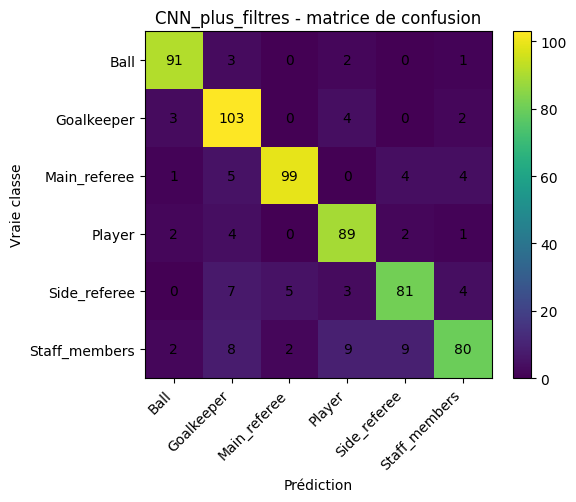

Modèle utilisé pour les feature maps : CNN_baseline


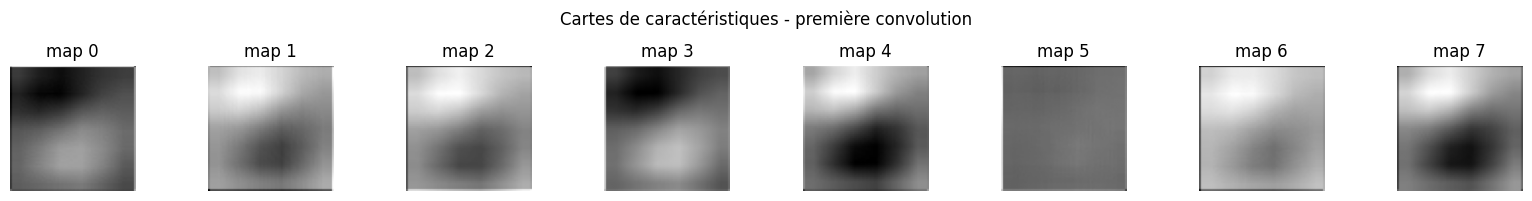

In [12]:
# ============================================================
# 2. Matrice de confusion et visualisation des feature maps
# ============================================================

best_cnn_name = cnn_results_df.iloc[0]["model"]
best_cnn = trained_cnn_models[best_cnn_name].to(DEVICE)
print("Meilleur modèle image :", best_cnn_name)

_, _, y_true_img, y_pred_img = evaluate_classifier(best_cnn, test_loader_img, device=DEVICE, return_preds=True)
plot_confusion_matrix_simple(
    y_true_img,
    y_pred_img,
    img_class_names,
    f"{best_cnn_name} - matrice de confusion",
    "cnn_confusion_matrix.png",
)

# Feature maps : on force l'interprétation sur un vrai CNN, même si le meilleur score vient du MLP image.
feature_model_name = "CNN_baseline" if "CNN_baseline" in trained_cnn_models else best_cnn_name
feature_model = trained_cnn_models[feature_model_name].to(DEVICE)
print("Modèle utilisé pour les feature maps :", feature_model_name)

if hasattr(feature_model, "features"):
    feature_model.eval()
    xb, yb = next(iter(test_loader_img))
    x_one = xb[:1].to(DEVICE)
    with torch.no_grad():
        first_conv = feature_model.features[0]
        fmap = first_conv(x_one).cpu()[0]

    n_maps = min(8, fmap.shape[0])
    fig, axes = plt.subplots(1, n_maps, figsize=(2*n_maps, 2))
    if n_maps == 1:
        axes = [axes]
    for i in range(n_maps):
        axes[i].imshow(fmap[i], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"map {i}")
    fig.suptitle("Cartes de caractéristiques - première convolution")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cnn_feature_maps.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Aucun modèle CNN disponible pour les feature maps.")


## Analyse critique — Partie II : CNN et vision par ordinateur

Après exécution du notebook de la Partie II, les résultats montrent que les réseaux de neurones convolutifs sont plus adaptés que les MLP pour la classification d’images.  
Le dataset utilisé contient **4 200 crops** extraits des annotations YOLO. Les images sont réparties de manière équilibrée entre **6 classes** :

- `Ball`
- `Goalkeeper`
- `Main_referee`
- `Player`
- `Side_referee`
- `Staff_members`

Chaque classe contient environ **700 images**. Cet équilibre est important, car il évite que le modèle apprenne principalement une classe dominante. Le découpage utilisé est de **2 940 images pour l’entraînement**, **630 pour la validation** et **630 pour le test**.

---

### 1. Comparaison entre le MLP image et le CNN

Le MLP image aplatie transforme chaque image en un simple vecteur de pixels. Cette transformation détruit une partie importante de la structure spatiale de l’image. Les relations entre pixels voisins, les contours, les formes et les textures ne sont donc plus explicitement exploitées.

Les résultats confirment cette limite :

| Modèle | Accuracy | F1-score |
|---|---:|---:|
| MLP image aplatie | 75,40 % | 75,59 % |
| Meilleur CNN — `CNN_plus_filtres` | 86,19 % | 86,10 % |

Le CNN généralise donc mieux que le MLP aplati. Cette différence s’explique par le biais inductif des CNN : ils exploitent la **localité**, le **partage des poids** et la **hiérarchie des représentations**. Les filtres convolutionnels permettent de détecter des motifs visuels utiles comme les contours, les silhouettes, les textures, les couleurs ou la forme du ballon.

---

### 2. Effet du padding

Le padding consiste à ajouter des pixels autour de l’image afin de mieux conserver les informations situées sur les bords. Sans padding, les cartes de caractéristiques diminuent plus rapidement après chaque convolution, ce qui peut provoquer une perte d’information.

Dans cette expérience :

| Modèle | F1-score |
|---|---:|
| `CNN_baseline` avec padding | 85,85 % |
| `CNN_sans_padding` | 84,22 % |

Le modèle avec padding obtient donc un résultat légèrement meilleur. Cela montre que conserver les informations aux bords peut être utile, surtout lorsque certains objets sont proches des limites du crop.

---

### 3. Effet du stride

Le stride représente le pas de déplacement du filtre convolutionnel. Un stride plus grand réduit plus rapidement la résolution spatiale des cartes de caractéristiques. Cela peut accélérer le calcul, mais aussi supprimer des détails importants.

Dans cette expérience, le modèle `CNN_stride_2` obtient environ **84,11 % de F1-score**, ce qui est inférieur au modèle baseline. Cela montre qu’une réduction trop rapide de la résolution peut entraîner une perte d’informations utiles.

Cette perte est particulièrement importante pour les petits objets comme le ballon ou pour distinguer des classes visuellement proches, par exemple `Main_referee`, `Side_referee` et `Staff_members`.

---

### 4. Effet du pooling

Le pooling réduit la taille des cartes de caractéristiques. Deux types de pooling ont été comparés :

| Type de pooling | Effet principal |
|---|---|
| Max-pooling | Garde les activations les plus fortes |
| Average-pooling | Moyenne les activations locales |

Le max-pooling conserve mieux les informations discriminantes, comme un contour fort ou une zone très activée. L’average-pooling lisse davantage les informations, ce qui peut réduire la capacité du modèle à détecter des détails importants.

Résultats observés :

| Modèle | F1-score |
|---|---:|
| `CNN_baseline` avec max-pooling | 85,85 % |
| `CNN_avg_pooling` | 84,05 % |

Le max-pooling est donc plus pertinent dans cette expérience.

---

### 5. Effet du nombre de filtres

Augmenter le nombre de filtres permet au CNN d’apprendre plus de motifs visuels différents. Chaque filtre peut se spécialiser dans un type d’information : contours, couleurs, textures, silhouettes, forme du ballon ou détails vestimentaires.

Dans cette expérience, le modèle `CNN_plus_filtres` obtient le meilleur résultat avec environ **86,10 % de F1-score**. Cela montre que l’augmentation du nombre de filtres améliore la capacité du modèle.

Cependant, cette amélioration a un coût : plus de filtres signifie plus de paramètres, donc un entraînement plus coûteux et un risque plus élevé de surapprentissage si le dataset est trop petit. Ici, le dataset est équilibré, ce qui limite en partie ce risque.

---

### 6. Effet de la convolution 1×1

La convolution `1×1` permet de recombiner les canaux sans modifier la résolution spatiale. Elle agit comme une transformation locale entre les canaux et peut enrichir les représentations apprises.

Dans cette expérience, le modèle `CNN_conv_1x1` obtient environ **81,78 % de F1-score**, ce qui est inférieur au CNN baseline. Ce résultat ne signifie pas que la convolution `1×1` est inutile. Il montre plutôt que, dans cette architecture simple, elle n’a pas apporté d’amélioration claire.

Elle pourrait devenir plus utile dans une architecture plus profonde ou mieux optimisée.

---

### 7. Interprétation des feature maps

Les feature maps visualisées montrent que les premières couches du CNN apprennent des informations visuelles simples. On observe des activations liées à des zones de contraste, des contours, des formes locales ou des textures.

Cela confirme le fonctionnement attendu d’un CNN :

| Niveau du réseau | Type d’informations apprises |
|---|---|
| Premières couches | Contours, contrastes, textures simples |
| Couches intermédiaires | Formes locales et combinaisons de motifs |
| Couches profondes | Représentations plus abstraites liées aux classes |

Les feature maps montrent donc que le modèle ne se contente pas de mémoriser les images. Il apprend progressivement des représentations utiles pour distinguer les différentes classes.

---

### Conclusion critique

Les résultats de la Partie II confirment clairement que le CNN est plus pertinent qu’un MLP pour la classification d’images. Le meilleur CNN atteint environ **86,10 % de F1-score**, contre **75,59 %** pour le MLP image aplatie.

Cette différence montre que la structure spatiale des images est essentielle. Le CNN l’exploite grâce aux filtres convolutionnels, au partage des poids et à la hiérarchie des représentations.

Les choix architecturaux influencent aussi les performances :

- le padding aide à conserver les informations aux bords ;
- un stride trop grand peut faire perdre des détails ;
- le max-pooling conserve mieux les activations importantes que l’average-pooling ;
- plus de filtres augmente la capacité du modèle ;
- la convolution `1×1` n’a pas amélioré les résultats dans cette configuration ;
- les feature maps confirment l’apprentissage progressif de motifs visuels.

Les principales limites viennent de la qualité des crops, de la proximité visuelle entre certaines classes et du nombre limité d’époques. Pour améliorer les performances, il serait possible d’utiliser de la data augmentation, d’entraîner plus longtemps ou de comparer avec des architectures plus modernes comme ResNet, EfficientNet ou Vision Transformer.

## Question de synthèse — Partie II

**Réponse attendue dans le rapport :**

Un CNN est plus pertinent qu'un MLP pour la classification d'images car il conserve la géométrie de l'image et apprend des motifs locaux réutilisables. Le padding influence la conservation des informations aux bords, le stride contrôle la réduction spatiale, le pooling résume les activations et la profondeur augmente le niveau d'abstraction des représentations. La comparaison expérimentale entre MLP image et CNN permet de vérifier concrètement que la structure convolutionnelle est mieux adaptée à une donnée visuelle.
